In [1]:
from itertools import accumulate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import RocCurveDisplay

In [2]:
dataset_dir = Path('datasets')
results_dir = Path('results')

## PPCA

In [3]:
train_data = np.load(dataset_dir / 'pav_features/train_split.npy')
valid_data = np.load(dataset_dir / 'pav_features/valid_split.npy')
iterations = sorted(list((results_dir / 'ppca').glob('iteration_*')))
iteration_defec = []
iteration_clean = []
defec_loglike = []
clean_loglike = []
evals = []
for iteration in iterations:
    valid_eval = np.load(iteration / 'valid.npy')
    evals.append(valid_eval)
    defec_mask = valid_eval[:, 0].astype(bool)
    defec_loglike.append(valid_eval[defec_mask, 1].mean())
    clean_loglike.append(valid_eval[~defec_mask, 1].mean())
    with (iteration / 'defec_image_paths.txt').open('r') as f:
        iteration_defec.append(f.read().splitlines())
    with (iteration / 'clean_image_paths.txt').open('r') as f:
        iteration_clean.append(f.read().splitlines())

### Resumo

In [4]:
total_defec = train_data[:, -1].sum()
total_clean = train_data.shape[0] - total_defec
exp_total_defec = sum(len(imgs) for imgs in iteration_defec)
exp_total_clean = sum(len(imgs) for imgs in iteration_clean)

print(
    'Conjunto total     : %4d com defeitos, %4d sem defeitos [%5.2f%%]'
    %(total_defec, total_clean, total_defec / train_data.shape[0] * 100)
)
print(
    'Subconjunto obtido : %4d com defeitos, %4d sem defeitos [%5.2f%%]'
    %(exp_total_defec, exp_total_clean,
      exp_total_defec / (exp_total_defec + exp_total_clean) * 100)
)
print(
    'Foram encontradas %.2f%% das imagens com defeitos.' %
    (exp_total_defec / total_defec * 100)
)

Conjunto total     :  441 com defeitos, 4312 sem defeitos [ 9.28%]
Subconjunto obtido :  207 com defeitos,  793 sem defeitos [20.70%]
Foram encontradas 46.94% das imagens com defeitos.


### Número de imagens com defeito encontradas em cada iteração
A expectativa é que o número de imagens com defeitos aumente em cada nova seleção de imagens, umas vez que as imagens selecionadas são aquelas com as menores probabilidade segundo a distribuição marginal das imagens sem defeitos.

In [5]:
clean_counts = [len(paths) for paths in iteration_clean]
defec_counts = [len(paths) for paths in iteration_defec]

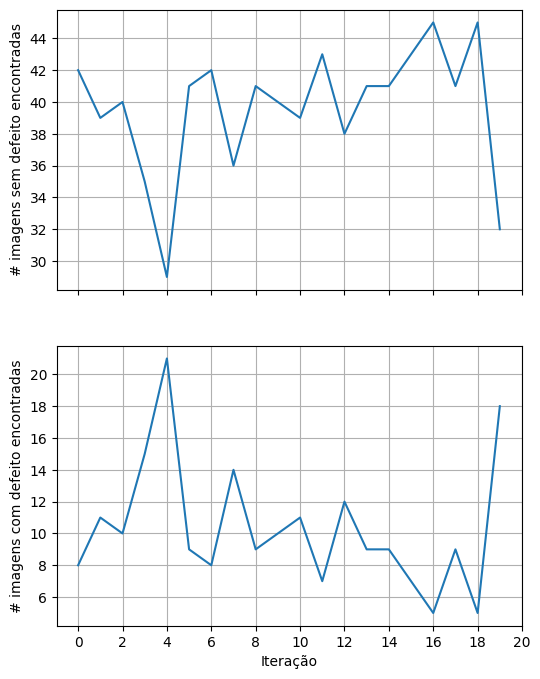

In [6]:
fig, (cl_count, df_count) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
# Imagens sem defeito
cl_count.plot(clean_counts)
cl_count.set_ylabel('# imagens sem defeito encontradas')
cl_count.grid(True)
# Imagens com defeito
df_count.plot(defec_counts)
df_count.set_xlabel('Iteração')
df_count.set_xticks(range(0, len(defec_counts) + 1, 2))
df_count.set_ylabel('# imagens com defeito encontradas')
df_count.grid(True)

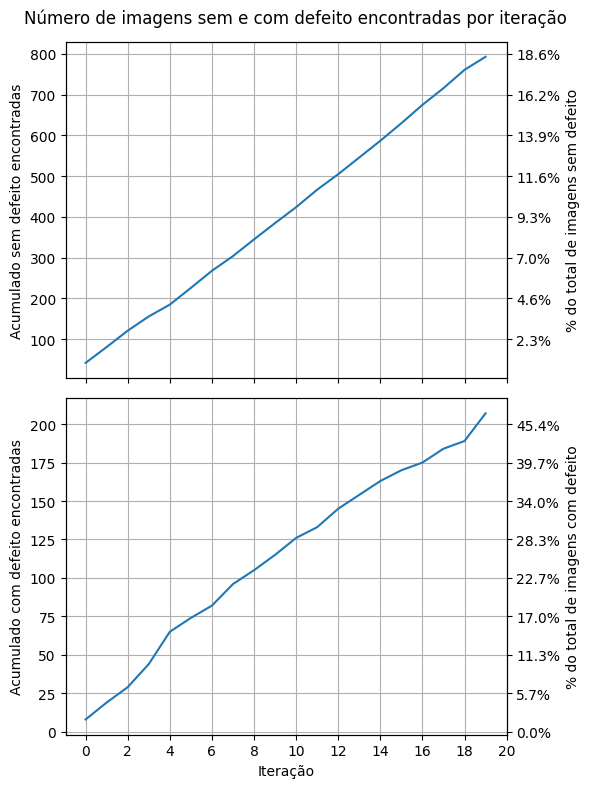

In [7]:
clean_accumu = list(accumulate(clean_counts))
defec_accumu = list(accumulate(defec_counts))
total_defec = train_data[:, -1].sum()
total_clean = train_data.shape[0] - total_defec

fig, (cl_accum, df_accum) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
# Imagens sem defeito acumuladas
cl_accum.plot(clean_accumu)
cl_accum.set_ylabel('Acumulado sem defeito encontradas')
cl_accum.grid(True)
cl_rc_accum = cl_accum.twinx()
cl_rc_accum.set_ylim(cl_accum.get_ylim())
formatter = mticker.PercentFormatter(xmax=total_clean)
cl_rc_accum.yaxis.set_major_formatter(formatter)
cl_rc_accum.set_ylabel('% do total de imagens sem defeito')
# Imagens com defeito acumuladas
df_accum.plot(defec_accumu)
df_accum.set_ylabel('Acumulado com defeito encontradas')
df_accum.set_xlabel('Iteração')
df_accum.set_xticks(range(0, len(defec_counts) + 1, 2))
df_accum.grid(True)
df_rc_accum = df_accum.twinx()
df_rc_accum.set_ylim(df_accum.get_ylim())
formatter = mticker.PercentFormatter(xmax=total_defec)
df_rc_accum.yaxis.set_major_formatter(formatter)
df_rc_accum.set_ylabel('% do total de imagens com defeito')

fig.suptitle('Número de imagens sem e com defeito encontradas por iteração')
plt.tight_layout()
plt.show()

### Avaliação das distribuições segundo conjunto de validação

#### Log-verossimilhança média

Com o passar das iterações e novas imagens sem defeitos surgem, a expectativa é que a estimação de densidade das imagens sem defeitos melhore. Essa melhora pode ser mensurada usando o conjunto de validação. Espera-se que a log-verossimilhança média das imagens sem defeitos presentes no conjunto de validação aumente com o passar das iterações e que a log-verossimilhança média das imagens com defeitos diminua.

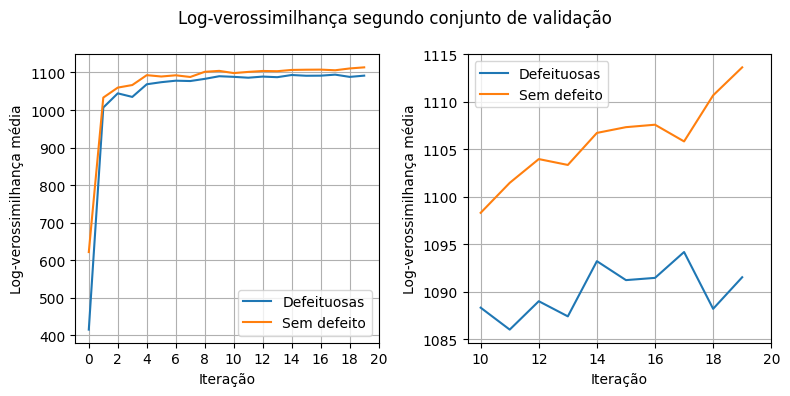

In [8]:
fig, (df_count, df_accum) = plt.subplots(1, 2, figsize=(8, 4))

df_count.plot(defec_loglike, label='Defeituosas')
df_count.plot(clean_loglike, label='Sem defeito')
df_count.set_xlabel('Iteração')
df_count.set_ylabel('Log-verossimilhança média')
df_count.set_xticks(range(0, len(defec_loglike) + 1, 2))
df_count.grid(True)
df_count.legend()

mid_iteration = len(defec_loglike) // 2
df_accum.plot(range(mid_iteration, len(defec_loglike)), defec_loglike[mid_iteration:], label='Defeituosas')
df_accum.plot(range(mid_iteration, len(clean_loglike)), clean_loglike[mid_iteration:], label='Sem defeito')
df_accum.set_xlabel('Iteração')
df_accum.set_ylabel('Log-verossimilhança média')
df_accum.set_xticks(range(mid_iteration, len(defec_loglike) + 1, 2))
df_accum.grid(True)
df_accum.legend()

fig.suptitle('Log-verossimilhança segundo conjunto de validação')
plt.tight_layout()
plt.show()

#### Curvas ROC

A cada iteração, novas estimações de densidade são obtidas. Outra forma de avaliar a qualidade da estimação da distribuição marginal $p_{limpas}(x)$ é analisando a curva ROC obtida a partir dos rótulos e dos valores de logpdf da distribuição marginal para cada imagem no conjunto de validação.

Uma vez que a curva ROC espera pontuações maiores para a classe alvo (anomalias, ou seja, imagens com defeitos), em vez da pontuação ser $\log{p_{limpas}(x_{vi})}$ ($x_{vi}$ sendo a i-ésima imagem do conjunto de validação) ela será a negativa desse valor.

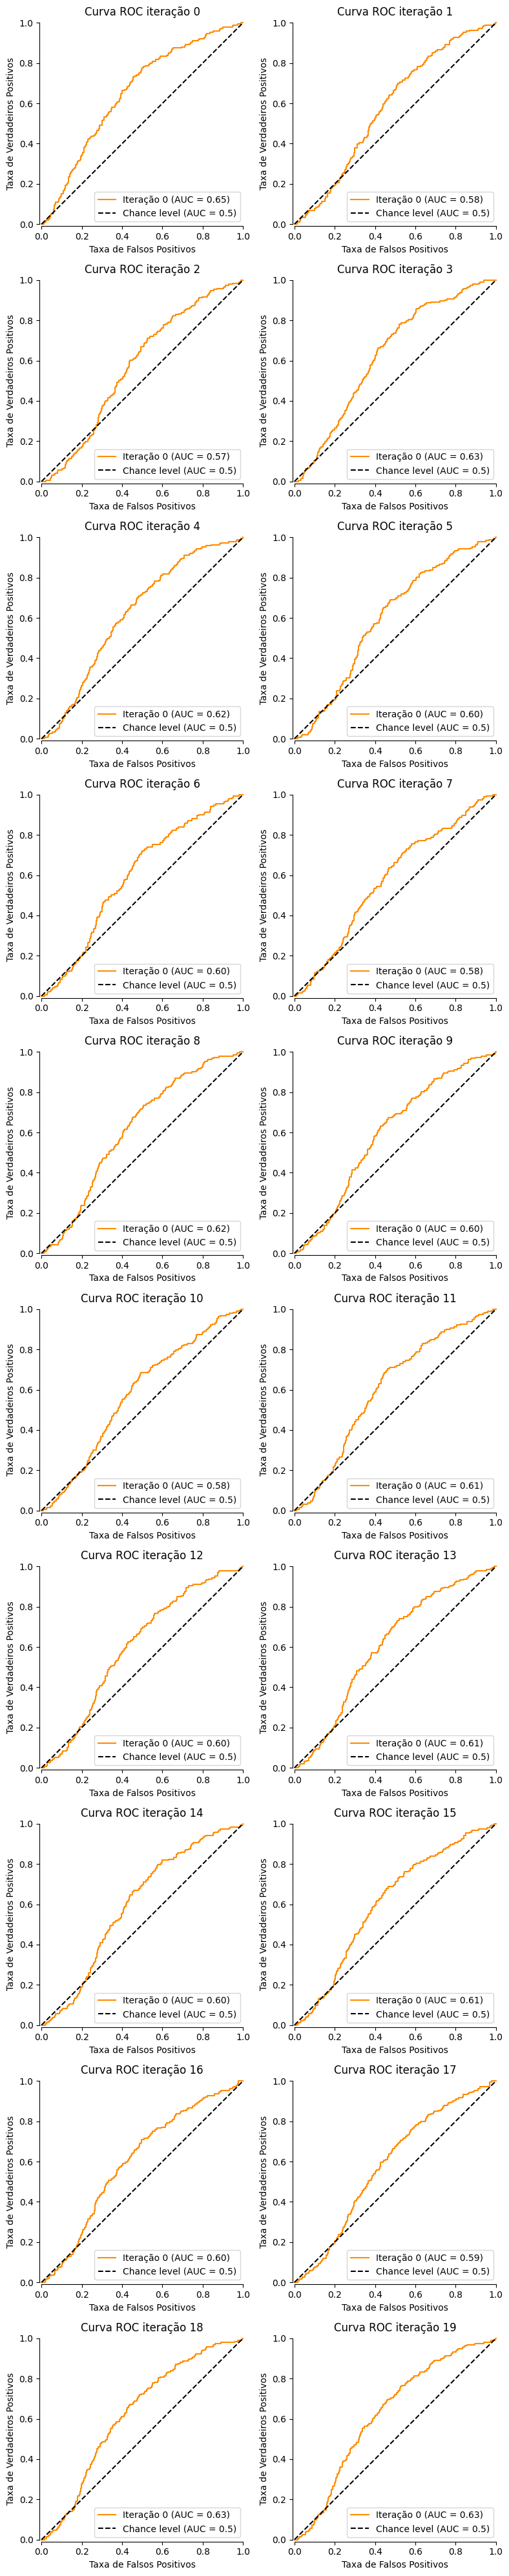

In [9]:
num_images = accumulate([len(p) for p in iteration_clean])
fig, axs = plt.subplots(10, 2, figsize=(8, 40))

for iteration, valid_eval in enumerate(evals):
    i, j = divmod(iteration, 2)
    ax = axs[i, j]
    display = RocCurveDisplay.from_predictions(
        evals[iteration][:, 0],
        -evals[iteration][:, 1],
        name='Iteração 0',
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
        ax=axs[i, j],
    )
    display.ax_.set(
        title=f'Curva ROC iteração {iteration}',
        xlabel='Taxa de Falsos Positivos',
        ylabel='Taxa de Verdadeiros Positivos',
    )
plt.tight_layout()
plt.show()